# 05 · Climate Model + Warming Scenario

**갈래 1 — 기후 모델**: 1981–2015 온도 노출/열지표의 추세를 연도·지역으로 학습 (교수님 요구).
**갈래 2 — 시나리오 생성**: 06 최적화에 넘길 **+2℃ 온난화 시 이동된 온도 분포**를 물리적으로 타당하게 생성.

---

### 04에서 넘어온 결정적 제약 (반드시 준수)
1. **수확량 모델(LightGBM)은 트리 기반 → 학습범위(1981–2015) 밖 외삽 불가.**
   시나리오는 `year`를 예측하지 않는다. **`year`는 2015로 고정**하고 온도 노출 분포만 이동시킨다.
2. **각 행의 gdd 121구간 합은 항상 184일.** 시나리오도 **합을 보존**한다 (이동만, 더하기 금지).

### 시나리오 파라미터
`DELTA_T = 2.0` (파리협정 상징선). 하드코딩하지 않고 파라미터로 두어 +1/+3℃ 로 값만 바꿔 재실행 가능.
비교 상태는 **baseline (ΔT=0)** 과 **+2℃** 두 개.

In [16]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

RAW = Path('..') / 'data' / 'raw'          # 읽기 전용
PROC = Path('..') / 'data' / 'processed'
FIG = Path('..') / 'outputs' / 'figures'
RES = Path('..') / 'outputs' / 'results'
FIG.mkdir(parents=True, exist_ok=True); RES.mkdir(parents=True, exist_ok=True)

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
CAT4 = [BLUE, AQUA, YELLOW, VIOLET]
DIVERGING = LinearSegmentedColormap.from_list('rd_gy_bl', [RED, '#f0efec', BLUE])

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

# ---------- 시나리오 파라미터 ----------
DELTA_T = 2.0
SCENARIOS = {'baseline': 0.0, 'plus%gC' % DELTA_T: DELTA_T}
YEAR_FIXED = 2015                 # 트리 모델 외삽 금지 -> year 고정
NORMAL_WINDOW = (2006, 2015)      # 기후 평년값 산출 구간
SUM_TOL = 0.1                     # 행 합이 184에서 이만큼 벗어나면 결손으로 간주
print('SCENARIOS:', SCENARIOS, '| year 고정 =', YEAR_FIXED, '| 평년 구간 =', NORMAL_WINDOW)

# ---------- 로드 ----------
panel = pd.read_parquet(PROC / 'corn_panel.parquet')
spec = json.load(open(PROC / 'feature_columns.json', encoding='utf-8'))
bundle = joblib.load(PROC / 'yield_model_final.joblib')
model, FEATS = bundle['model'], bundle['features']
print('yield model:', bundle['model_name'], '전략', bundle['strategy'], '| CV R2 %.4f' % bundle['cv_r2_mean'])

GDD = [c for c in panel.columns if c.startswith('gdd')]
def temp_of(c):
    return 0 if c == 'gdd0' else (int(c[4:]) if c.startswith('gddp') else -int(c[4:]))
TEMPS = np.array([temp_of(c) for c in GDD])
SOIL = spec['strategy_A']['soil']
FEAT_BINS = spec['strategy_B']['gdd_bins']            # 86개
REF_BIN = spec['strategy_B']['reference_bin_dropped'] # gddp24
KEEP_BINS = FEAT_BINS + [REF_BIN]                     # 87개 = 모델이 '보는' 온도 공간
kt = np.array([temp_of(c) for c in KEEP_BINS])
LO_T, HI_T = int(kt.min()), int(kt.max())
DAYS = 184.0
print('모델 온도 공간: %d 구간, %d℃ ~ %d℃ (reference %s 포함)' % (len(KEEP_BINS), LO_T, HI_T, REF_BIN))

# gddm4 결측 1개 복원 (총합 제약)
_m = panel['gddm4'].isna()
if _m.any():
    panel.loc[_m, 'gddm4'] = DAYS - panel.loc[_m, [c for c in GDD if c != 'gddm4']].sum(axis=1)
    print('corn_panel gddm4 결측 %d행 복원' % int(_m.sum()))

# 지역 구분 (US Census region)
REGION_OF = {}
for s in [9, 23, 25, 33, 44, 50, 34, 36, 42]: REGION_OF[s] = 'Northeast'
for s in [17, 18, 26, 39, 55, 19, 20, 27, 29, 31, 38, 46]: REGION_OF[s] = 'Midwest'
for s in [10, 11, 12, 13, 24, 37, 45, 51, 54, 1, 21, 28, 47, 5, 22, 40, 48]: REGION_OF[s] = 'South'
for s in [4, 8, 16, 30, 32, 35, 49, 56, 2, 6, 15, 41, 53]: REGION_OF[s] = 'West'
REGIONS = ['Midwest', 'Northeast', 'South', 'West']
panel['state'] = panel['stco'] // 1000
panel['region'] = panel['state'].map(REGION_OF)
assert panel['region'].notna().all()
COUNTIES = np.sort(panel['stco'].unique())
print('패널: %d행 / %d 카운티' % (len(panel), len(COUNTIES)))

SCENARIOS: {'baseline': 0.0, 'plus2C': 2.0} | year 고정 = 2015 | 평년 구간 = (2006, 2015)
yield model: RandomForest 전략 B | CV R2 0.7362
모델 온도 공간: 87 구간, -36℃ ~ 50℃ (reference gddp24 포함)
corn_panel gddm4 결측 1행 복원
패널: 70721행 / 2644 카운티


## 1. 갈래 1 — 기후 모델

### 1-1. 열지표 정의 (카운티 × 연도)

| 지표 | 정의 | 단위 |
|---|---|---|
| `wmean_temp` | 노출가중 여름 평균기온 = Σ(일수ᵗ × t) / 184 | ℃ |
| `GDD_above_29` | 30℃ 이상 구간 노출 일수 합 (유해 고온) | 일 |
| `GDD_10_30` | Σ 일수ᵗ × (clip(t,10,30) − 10) — 옥수수 표준 생육열량(base 10℃, cap 30℃) | ℃·일 |

In [17]:
E_panel = panel[GDD].to_numpy()
row_sum = E_panel.sum(1)
panel['wmean_temp'] = (E_panel * TEMPS).sum(1) / row_sum
panel['GDD_above_29'] = E_panel[:, TEMPS >= 30].sum(1)
panel['GDD_10_30'] = (E_panel * (np.clip(TEMPS, 10, 30) - 10)).sum(1)
IDX = ['wmean_temp', 'GDD_above_29', 'GDD_10_30']
print('행 합: mean %.4f  std %.5f' % (row_sum.mean(), row_sum.std()))
print()
print(panel[IDX].describe().round(2).to_string())

행 합: mean 183.9996  std 0.01207

       wmean_temp  GDD_above_29  GDD_10_30
count    70721.00      70721.00   70721.00
mean        19.31         23.59    1871.50
std          3.39         16.80     439.59
min         10.07          0.00     614.28
25%         16.71          9.80    1527.98
50%         19.20         20.57    1839.43
75%         21.73         34.37    2173.41
max         31.03        109.07    3272.00


### 1-2. ⚠️ 먼저 짚어야 할 함정 — 구성 편향(composition bias)

패널은 **불균형**이다. `corn`이 NA인 행을 03에서 제거했기 때문에 **연도마다 카운티 구성이 달라진다**
(1981년 2,387개 → 2015년 1,433개). 이 상태로 "연도별 전국 평균"의 추세를 재면
**기후 변화가 아니라 카운티 구성 변화를 재게 된다.**

세 가지를 비교한다.
- **순진한 전국평균**: 매년 존재하는 카운티들의 단순 평균
- **균형 패널**: 35년 모두 존재하는 카운티(872개)만
- **카운티 고정효과(FE)**: 모든 행을 쓰되 카운티 내 변화만으로 추세 식별 ← **이것이 옳다**

In [18]:
cnt_by_county = panel.groupby('stco').size()
BAL = cnt_by_county[cnt_by_county == 35].index
print('균형 패널 카운티: %d / %d' % (len(BAL), len(COUNTIES)))
n_by_year = panel.groupby('year').size()
print('연도별 행 수: 1981 %d -> 2015 %d' % (n_by_year.iloc[0], n_by_year.iloc[-1]))

def fe_trend(df, col):
    """카운티 FE 내 연도 추세 (per decade) + 카운티 클러스터 로버스트 SE"""
    ci = pd.factorize(df['stco'])[0]; nc = ci.max() + 1
    cnt = np.bincount(ci).astype(float)
    dm = lambda v: np.asarray(v, float) - (np.bincount(ci, np.asarray(v, float), minlength=nc) / cnt)[ci]
    x = dm(df['year'].to_numpy(float)); yv = dm(df[col].to_numpy())
    b = (x * yv).sum() / (x * x).sum()
    u = yv - b * x
    order = np.argsort(ci); xs, us, cs = x[order], u[order], ci[order]
    bnd = np.searchsorted(cs, np.arange(nc + 1))
    meat = sum((xs[bnd[g]:bnd[g+1]] @ us[bnd[g]:bnd[g+1]]) ** 2 for g in range(nc))
    N = len(df); adj = (nc / (nc - 1)) * ((N - 1) / (N - 1 - nc))
    se = np.sqrt(meat / (x * x).sum() ** 2 * adj)
    return b * 10, se * 10

def naive_slope(df, col):
    yr = df.groupby('year')[col].mean()
    return np.polyfit(yr.index, yr.values, 1)[0] * 10

rows = []
for c in IDX:
    b_fe, se_fe = fe_trend(panel, c)
    rows.append({'index': c, 'naive': naive_slope(panel, c),
                 'balanced': naive_slope(panel[panel.stco.isin(BAL)], c),
                 'county_FE': b_fe, 'FE_se': se_fe, 'FE_t': b_fe / se_fe,
                 'FE_34yr': b_fe * 3.4})
comp = pd.DataFrame(rows)
print()
print('추세 (per decade)')
print(comp.round(4).to_string(index=False))
print()
print('=> 순진한 평균은 wmean_temp / GDD_above_29 에서 부호까지 뒤집힌다.')

균형 패널 카운티: 872 / 2644
연도별 행 수: 1981 2387 -> 2015 1433

추세 (per decade)
       index   naive  balanced  county_FE  FE_se    FE_t  FE_34yr
  wmean_temp -0.0352    0.0835     0.1224 0.0034 36.4523   0.4162
GDD_above_29 -0.4418   -0.1139     0.2756 0.0249 11.0503   0.9370
   GDD_10_30  1.0229   16.1129    20.5246 0.3869 53.0554  69.7836

=> 순진한 평균은 wmean_temp / GDD_above_29 에서 부호까지 뒤집힌다.


saved: ../outputs/figures/fig17_climate_trends.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/809231829.py:17: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/809231829.py:17: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/809231829.py:17: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/809231829.py:17: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.93])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/809231829.py:17: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
 

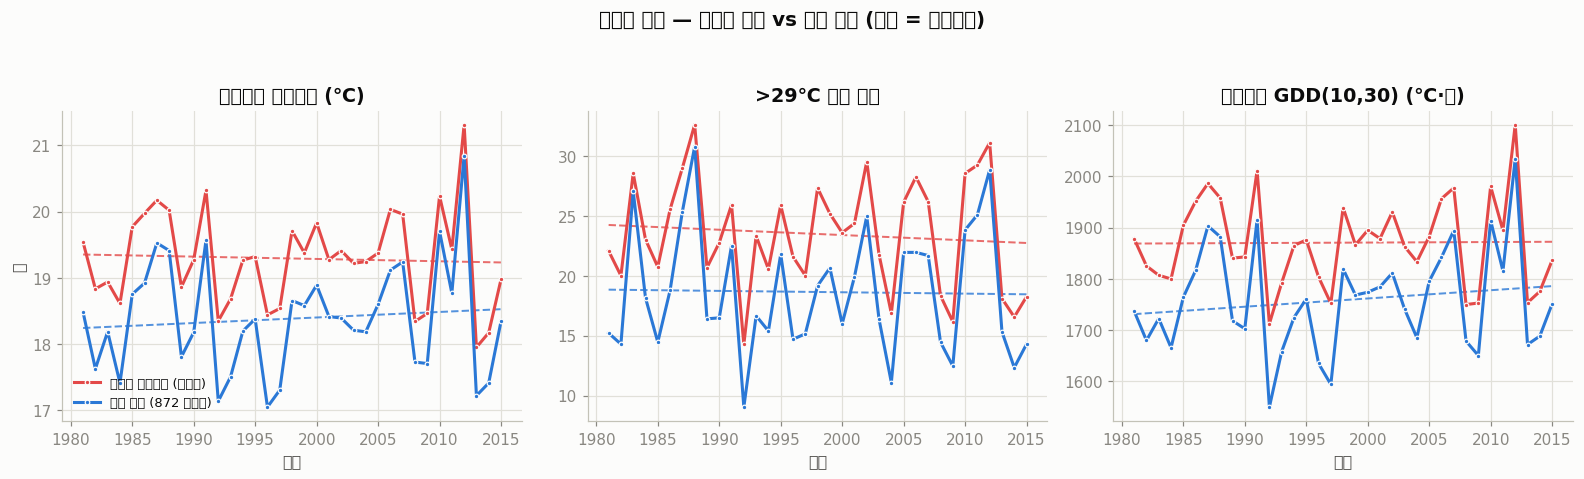

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
LABELS = {'wmean_temp': '노출가중 평균기온 (℃)', 'GDD_above_29': '>29℃ 노출 일수',
          'GDD_10_30': '생육열량 GDD(10,30) (℃·일)'}
for ax, c in zip(axes, IDX):
    ax.set_axisbelow(True)
    yr_all = panel.groupby('year')[c].mean()
    yr_bal = panel[panel.stco.isin(BAL)].groupby('year')[c].mean()
    for series, col, lab in [(yr_all, RED, '순진한 전국평균 (불균형)'), (yr_bal, BLUE, '균형 패널 (872 카운티)')]:
        ax.plot(series.index, series.values, color=col, marker='o', markersize=3,
                markeredgecolor=SURFACE, markeredgewidth=0.8, zorder=3, label=lab)
        s, i0 = np.polyfit(series.index, series.values, 1)
        ax.plot(series.index, i0 + s * series.index, color=col, linestyle='--', linewidth=1.3, alpha=0.8, zorder=2)
    ax.set_title(LABELS[c]); ax.set_xlabel('연도')
axes[0].set_ylabel('값')
axes[0].legend(frameon=False, fontsize=8.5, loc='lower left')
fig.suptitle('열지표 추세 — 순진한 평균 vs 균형 패널 (점선 = 선형추세)', fontsize=13, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, 'fig17_climate_trends.png'); plt.show()

### 1-3. 지역별 추세 + 교수님용 회귀 모델 (연도 + 지역 → 열지표)

In [20]:
reg_rows = []
for r in REGIONS:
    g = panel[panel.region == r]
    d = {'region': r, 'counties': g.stco.nunique()}
    for c in IDX:
        b, se = fe_trend(g, c)
        d[c] = b; d[c + '_t'] = b / se
    reg_rows.append(d)
regt = pd.DataFrame(reg_rows)
print('지역별 카운티 FE 추세 (per decade, t는 카운티 클러스터)')
print(regt.round(4).to_string(index=False))

# 교수님 요구: 연도 + 지역(주) 회귀
D = pd.get_dummies(panel['state'], prefix='st', drop_first=True).astype(float)
Xd = np.column_stack([np.ones(len(panel)), panel['year'].to_numpy(float), D.to_numpy()])
ols_rows = []
for c in IDX:
    yv = panel[c].to_numpy()
    b, *_ = np.linalg.lstsq(Xd, yv, rcond=None)
    r2 = 1 - ((yv - Xd @ b) ** 2).sum() / ((yv - yv.mean()) ** 2).sum()
    ols_rows.append({'index': c, 'year_per_decade': b[1] * 10, 'R2': r2, 'n_state_dummies': D.shape[1]})
ols = pd.DataFrame(ols_rows)
print()
print('연도 + 주(state) 더미 OLS  [교수님 요구: "추세가 존재하고 모델로 잡힌다"]')
print(ols.round(4).to_string(index=False))

trends_out = comp.merge(ols[['index', 'year_per_decade', 'R2']], on='index', suffixes=('', '_ols'))
trends_out.to_csv(RES / 'climate_trends.csv', index=False)
regt.to_csv(RES / 'climate_trends_by_region.csv', index=False)
print('\n저장:', RES / 'climate_trends.csv', '/', RES / 'climate_trends_by_region.csv')

지역별 카운티 FE 추세 (per decade, t는 카운티 클러스터)
   region  counties  wmean_temp  wmean_temp_t  GDD_above_29  GDD_above_29_t  GDD_10_30  GDD_10_30_t
  Midwest      1049      0.0597       12.1226       -0.2036         -7.2808    12.9814      24.2066
Northeast       134      0.2122       36.3056        0.1889          6.0915    31.7384      47.0704
    South      1208      0.1814       55.9377        0.7708         19.0248    27.8900      68.0204
     West       253      0.2220        9.8189        1.7296         13.5491    29.6728      10.8408

연도 + 주(state) 더미 OLS  [교수님 요구: "추세가 존재하고 모델로 잡힌다"]
       index  year_per_decade     R2  n_state_dummies
  wmean_temp           0.1605 0.8289               40
GDD_above_29           0.5298 0.7103               40
   GDD_10_30          25.4374 0.8254               40

저장: ../outputs/results/climate_trends.csv / ../outputs/results/climate_trends_by_region.csv


saved: ../outputs/figures/fig18_composition_and_regional.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3218651979.py:30: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3218651979.py:30: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3218651979.py:30: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3218651979.py:30: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3218651979.py:30: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipy

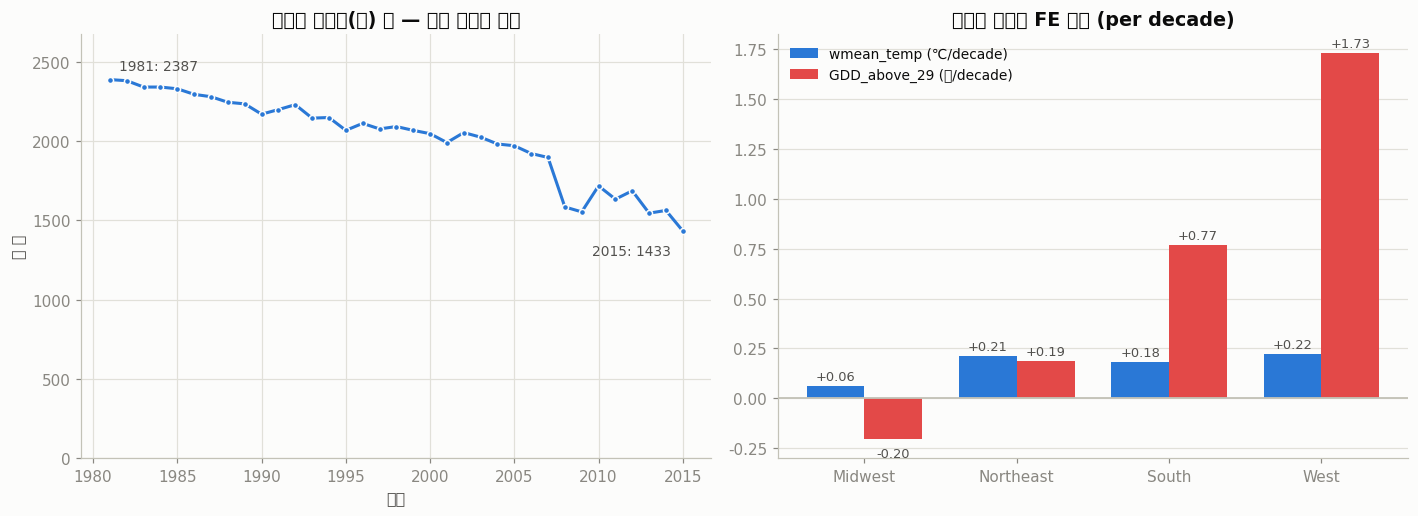

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]; ax.set_axisbelow(True)
ax.plot(n_by_year.index, n_by_year.values, color=BLUE, marker='o', markersize=4,
        markeredgecolor=SURFACE, markeredgewidth=1.0, zorder=3)
ax.set_ylim(0, n_by_year.max() * 1.12)
ax.set_title('연도별 카운티(행) 수 — 구성 편향의 원인')
ax.set_xlabel('연도'); ax.set_ylabel('행 수')
ax.annotate('1981: %d' % n_by_year.iloc[0], xy=(1981, n_by_year.iloc[0]), xytext=(6, 6),
            textcoords='offset points', color=SECOND, fontsize=9)
ax.annotate('2015: %d' % n_by_year.iloc[-1], xy=(2015, n_by_year.iloc[-1]), xytext=(-8, -16),
            textcoords='offset points', ha='right', color=SECOND, fontsize=9)

ax = axes[1]; ax.set_axisbelow(True); ax.grid(axis='x', visible=False)
xp = np.arange(len(REGIONS)); w = 0.38
a29 = regt.set_index('region').loc[REGIONS, 'GDD_above_29']
wmt = regt.set_index('region').loc[REGIONS, 'wmean_temp']
ax.bar(xp - w/2, wmt.values, width=w, color=BLUE, label='wmean_temp (℃/decade)')
ax.bar(xp + w/2, a29.values, width=w, color=RED, label='GDD_above_29 (일/decade)')
ax.axhline(0, color=AXIS, linewidth=1.2)
for i, v in enumerate(wmt.values):
    ax.annotate('%+.2f' % v, xy=(i - w/2, v), xytext=(0, 4 if v >= 0 else -12),
                textcoords='offset points', ha='center', fontsize=8.5, color=SECOND)
for i, v in enumerate(a29.values):
    ax.annotate('%+.2f' % v, xy=(i + w/2, v), xytext=(0, 4 if v >= 0 else -12),
                textcoords='offset points', ha='center', fontsize=8.5, color=SECOND)
ax.set_xticks(xp); ax.set_xticklabels(REGIONS)
ax.set_title('지역별 카운티 FE 추세 (per decade)')
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
save(fig, 'fig18_composition_and_regional.png'); plt.show()

**해석 — 온난화 추세는 존재하지만, 옥수수 주산지에서는 "극한 고온"이 오히려 줄었다.**

- **구성 편향이 결정적이다.** 순진한 전국평균은 `wmean_temp` **−0.035℃/decade**(냉각!), `GDD_above_29`
  **−0.44일/decade** 로 나온다. 이는 더운 남부 카운티들이 옥수수 재배를 그만두며 표본에서 빠진 탓이다.
  균형 패널로 보면 `wmean_temp` **+0.084**, 카운티 FE로 보면 **+0.122℃/decade (t=36.5)** 로 부호가 뒤집힌다.
- **전국 카운티 FE 추세 (1981–2015, 34년 누적)**
  - `wmean_temp` **+0.122℃/decade** (t=36.5) → 34년간 **+0.42℃**
  - `GDD_above_29` **+0.276일/decade** (t=11.1) → 34년간 **+0.94일**
  - `GDD_10_30` **+20.5 ℃·일/decade** (t=53.1) → 34년간 **+69.8**
- **지역차가 매우 크다.**
  - **Midwest(옥수수 벨트, 1,049개 카운티)**: 평균기온은 **+0.060℃/decade**로 가장 느리게 오르고,
    **`GDD_above_29`는 오히려 −0.204일/decade (t=−7.3)로 감소**한다. 이것이 문헌의 **"US warming hole"**
    현상이다 — 관개 확대·대기 순환 변화로 중서부 여름 극한고온이 억제됐다.
  - **West**: `GDD_above_29` **+1.73일/decade (t=13.5)** 로 가장 빠르게 악화. **South** +0.77.
- 교수님 요구 회귀(**연도 + 주 더미**)는 `wmean_temp` R²=0.83, `GDD_10_30` R²=0.83으로 추세를 잘 잡는다.
  연도 계수는 `wmean_temp` **+0.16℃/decade**.

> **⚠️ 외삽 불확실성 — 이 추세 모델로 미래를 예측하지 않는다.**
> (1) 34년 관측 추세는 `wmean_temp` 기준 **+0.42℃**에 불과하다. 이를 단순 선형 외삽하면 +2℃ 도달에
> **약 160년**이 걸린다. 즉 **+2℃ 시나리오는 이 회귀의 외삽이 아니다.**
> (2) 관측 추세는 강제력(온실가스)·에어로졸·관개 등이 섞인 결과이고, 중서부의 warming hole이
> 미래에도 지속된다는 보장이 없다.
> (3) 따라서 갈래 2의 시나리오는 **추세 모델에서 뽑지 않고**, IPCC식 **처방된 균일 +2℃ 이동**으로 만든다.
> 이 회귀의 역할은 "추세가 존재하며 연도·지역으로 설명된다"를 보이는 것까지다.

## 2. 갈래 2 — +2℃ 온난화 시나리오 생성

### 2-1. 베이스라인 = 기후 평년값 (2006–2015)

단일 연도(예: 2015)는 그 해의 날씨 잡음을 그대로 물려받는다. 기후학 관행대로 **최근 10년 평균 분포**를
카운티의 "현재 기후"로 삼는다.

- 노출 분포·강수: **`data/raw/`의 원자료에서 직접** 2006–2015 평균 (읽기 전용).
  `corn_panel`은 `corn`이 NA인 행을 뺐기 때문에 카운티당 연수가 들쭉날쭉하지만,
  **기후 자체는 모든 카운티×연도에 존재**한다 → 2,644개 카운티 전부 10년 확보.
- 토양·농지규모: `soil2011.csv`, `gridInfo.csv`의 `numAg2011` (2015년 예측에 맞는 스냅샷).
- `year` = 2015 고정.

> **원자료 결손 발견**: `gddMarAug.csv`의 일부 행은 121구간 합이 184가 아니다
> (전체 **293행 / 96개 카운티**, 최소 **156.86일**). 노출일수가 통째로 누락된 손상 행이다.
> 평년값 계산에서 **|합 − 184| > 0.1 인 행을 제외**한다 (평년 구간에서는 10행 제외).
>
> 이 중 **80행이 `corn_panel`에도 들어가 있어 02~04의 학습 데이터에 포함돼 있었다.**
> 70,721행 중 0.11%라 결과에 영향은 없지만, 앞선 노트북들이 놓친 데이터 품질 이슈로 기록해 둔다.

In [22]:
lo_y, hi_y = NORMAL_WINDOW

g = pd.read_csv(RAW / 'gddMarAug.csv').dropna(subset=['year'])
g['year'] = g['year'].astype(int)
_m = g['gddm4'].isna()
g.loc[_m, 'gddm4'] = DAYS - g.loc[_m, [c for c in GDD if c != 'gddm4']].sum(axis=1)
g['row_sum'] = g[GDD].sum(axis=1)

bad_all = g[np.abs(g['row_sum'] - DAYS) > SUM_TOL]
print('원자료 전체 결손 행: %d개 (카운티 %d개), 합 최소 %.3f'
      % (len(bad_all), bad_all.stco.nunique(), g['row_sum'].min()))
in_panel_keys = set(map(tuple, panel[['stco', 'year']].to_numpy()))
leak = sum(1 for t in map(tuple, bad_all[['stco', 'year']].to_numpy()) if t in in_panel_keys)
print('  그중 corn_panel(=04 학습데이터)에 유입된 행: %d개 -> 무시 가능' % leak)

win = g[(g.year.between(lo_y, hi_y)) & (g.stco.isin(COUNTIES))]
good = win[np.abs(win['row_sum'] - DAYS) <= SUM_TOL]
print('\n평년 구간 %d-%d: %d행 -> 결손 %d행 제외 -> %d행' % (lo_y, hi_y, len(win), len(win) - len(good), len(good)))

base_E = good.groupby('stco')[GDD].mean().reindex(COUNTIES)
n_years = good.groupby('stco').size().reindex(COUNTIES)
print('카운티당 사용 연수: min %d, max %d' % (n_years.min(), n_years.max()))
assert base_E.notna().all().all() and len(base_E) == len(COUNTIES)

ppt_raw = pd.read_csv(RAW / 'pptMarAug.csv').dropna(subset=['year'])
ppt_raw['year'] = ppt_raw['year'].astype(int)
base_ppt = (ppt_raw[(ppt_raw.year.between(lo_y, hi_y)) & (ppt_raw.stco.isin(COUNTIES))]
            .groupby('stco')['ppt'].mean().reindex(COUNTIES))

soil = pd.read_csv(RAW / 'soil2011.csv').set_index('stco').reindex(COUNTIES)
n_soil_na = int(soil[SOIL].isna().sum().sum())
soil[SOIL] = soil[SOIL].fillna(soil[SOIL].median())
A_c = pd.read_csv(RAW / 'gridInfo.csv').groupby('stco')['numAg2011'].sum().reindex(COUNTIES)
print('soil 결측 %d셀 -> 중앙값 대체 | A_c 결측 %d' % (n_soil_na, int(A_c.isna().sum())))

bs = base_E.sum(axis=1)
print('\n베이스라인 분포 합: mean %.6f  min %.6f  max %.6f' % (bs.mean(), bs.min(), bs.max()))
assert np.abs(bs - DAYS).max() < SUM_TOL

원자료 전체 결손 행: 293개 (카운티 96개), 합 최소 156.862
  그중 corn_panel(=04 학습데이터)에 유입된 행: 80개 -> 무시 가능

평년 구간 2006-2015: 26440행 -> 결손 10행 제외 -> 26430행
카운티당 사용 연수: min 7, max 10
soil 결측 0셀 -> 중앙값 대체 | A_c 결측 0

베이스라인 분포 합: mean 183.999940  min 183.981521  max 184.000000


### 2-2. 온도 분포 이동 함수

온도축은 −60…+60℃의 1℃ 격자다. ΔT만큼 **오른쪽(따뜻한 쪽)으로 이동**한다.

- **정수부** `k = floor(ΔT)` 는 격자 이동, **소수부** `frac` 는 인접 두 구간에 비례 배분
  (ΔT=2.0이면 frac=0이라 순수 정수 이동이지만, +1.5℃ 등에도 쓸 수 있게 일반화).
- **경계 처리**: 모델이 보는 온도 공간은 **−36℃ ~ +50℃**(87구간)뿐이다. 이동 후 이 범위를 벗어난 질량은
  **경계 구간에 접어 넣는다(fold)**. 버리면 합 184가 깨지고, 모델 입력에서 노출일수가 증발한다.
- **합 보존**은 `assert`로 검증한다.

In [23]:
I_LO = int(np.where(TEMPS == LO_T)[0][0])
I_HI = int(np.where(TEMPS == HI_T)[0][0])

def shift_distribution(E, dT):
    """E: (n, 121) 노출일수. +dT℃ 이동. [LO_T, HI_T] 밖 질량은 경계에 fold. 합 정확히 보존."""
    n, k = E.shape
    ki = int(np.floor(dT)); frac = dT - ki

    def roll_fold(M, s):
        out = np.zeros_like(M)
        tgt = np.clip(np.arange(k) + s, 0, k - 1)      # 격자 밖은 끝 구간에 누적
        for j in range(k):
            out[:, tgt[j]] += M[:, j]
        return out

    S = (1 - frac) * roll_fold(E, ki)
    if frac > 0:
        S = S + frac * roll_fold(E, ki + 1)

    spilled_hi = S[:, I_HI + 1:].sum()
    spilled_lo = S[:, :I_LO].sum()
    out = S.copy()
    out[:, I_HI] += S[:, I_HI + 1:].sum(1); out[:, I_HI + 1:] = 0.0
    out[:, I_LO] += S[:, :I_LO].sum(1);     out[:, :I_LO] = 0.0

    assert np.allclose(out.sum(1), E.sum(1), atol=1e-9), '합 보존 실패'
    return out, spilled_hi, spilled_lo

E_base_raw = base_E.to_numpy()
scen_E, scen_meta = {}, {}
for name, dT in SCENARIOS.items():
    Es, sh, sl = shift_distribution(E_base_raw, dT)
    scen_E[name] = Es; scen_meta[name] = dict(delta_t=dT, spill_hi=sh, spill_lo=sl)
    print('%-10s ΔT=%.1f | 합 mean %.6f (max|Δ| vs baseline %.2e) | 상단 fold %.4f day-rows | 하단 fold %.4f'
          % (name, dT, Es.sum(1).mean(), np.abs(Es.sum(1) - E_base_raw.sum(1)).max(), sh, sl))

BASE, WARM = 'baseline', 'plus%gC' % DELTA_T

# ΔT=0 도 fold는 일어난다: 원자료 평년값에는 모델 온도공간(-36℃) 아래에 극소량의 질량이 있다.
# (corn_panel 에는 없던, corn=NA 연도의 한랭 카운티 노출)
base_fold = np.abs(scen_E[BASE] - E_base_raw).sum()
print('\nΔT=0 에서도 fold된 질량: %.6f day-rows (하단 %.6f) -> 모델이 184일 전부 보도록 경계에 접음'
      % (base_fold, scen_meta[BASE]['spill_lo']))
assert base_fold < 0.01, 'baseline fold 량이 예상보다 큼'
assert np.allclose(scen_E[BASE].sum(1), E_base_raw.sum(1), atol=1e-9)

wm = {k: (v * TEMPS).sum(1) / v.sum(1) for k, v in scen_E.items()}
shift_obs = (wm[WARM] - wm[BASE]).mean()
print('\n노출가중 평균기온 이동량: %.6f℃ (목표 %.1f℃)' % (shift_obs, DELTA_T))
assert abs(shift_obs - DELTA_T) < 1e-3, '이동량 불일치'
print('=> 합 184 보존 + 평균기온 정확히 +%.1f℃ 이동 확인' % DELTA_T)

baseline   ΔT=0.0 | 합 mean 183.999940 (max|Δ| vs baseline 1.42e-13) | 상단 fold 0.0000 day-rows | 하단 fold 0.0004
plus2C     ΔT=2.0 | 합 mean 183.999940 (max|Δ| vs baseline 1.42e-13) | 상단 fold 0.0400 day-rows | 하단 fold 0.0000

ΔT=0 에서도 fold된 질량: 0.000863 day-rows (하단 0.000432) -> 모델이 184일 전부 보도록 경계에 접음

노출가중 평균기온 이동량: 2.000000℃ (목표 2.0℃)
=> 합 184 보존 + 평균기온 정확히 +2.0℃ 이동 확인


In [24]:
a29_mask = TEMPS >= 30
b29_mask = (TEMPS >= 1) & (TEMPS <= 29)
above = {k: v[:, a29_mask].sum(1) for k, v in scen_E.items()}
below = {k: v[:, b29_mask].sum(1) for k, v in scen_E.items()}
g1030 = {k: (v * (np.clip(TEMPS, 10, 30) - 10)).sum(1) for k, v in scen_E.items()}

d_a29 = above[WARM] - above[BASE]
print('GDD_above_29:  baseline %.2f일 -> %s %.2f일   (평균 %+.2f일)'
      % (above[BASE].mean(), WARM, above[WARM].mean(), d_a29.mean()))
print('  증가한 카운티: %d / %d (%.1f%%)' % ((d_a29 > 0).sum(), len(d_a29), 100 * (d_a29 > 0).mean()))
print('  Δ 최소 %+.2f일, 최대 %+.2f일, 중앙값 %+.2f일' % (d_a29.min(), d_a29.max(), np.median(d_a29)))
print('GDD_below_29:  %.2f -> %.2f (%+.2f일)' % (below[BASE].mean(), below[WARM].mean(), (below[WARM]-below[BASE]).mean()))
assert (d_a29 > 0).all(), '+2℃ 인데 고온 노출이 안 늘어난 카운티가 있음'

GDD_above_29:  baseline 26.49일 -> plus2C 41.20일   (평균 +14.71일)
  증가한 카운티: 2644 / 2644 (100.0%)
  Δ 최소 +0.34일, 최대 +29.03일, 중앙값 +15.12일
GDD_below_29:  150.41 -> 138.23 (-12.18일)


saved: ../outputs/figures/fig19_scenario_distributions.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/463122701.py:20: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.90])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/463122701.py:20: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.90])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/463122701.py:20: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.90])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/463122701.py:20: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.90])
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/463122701.py:20: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig

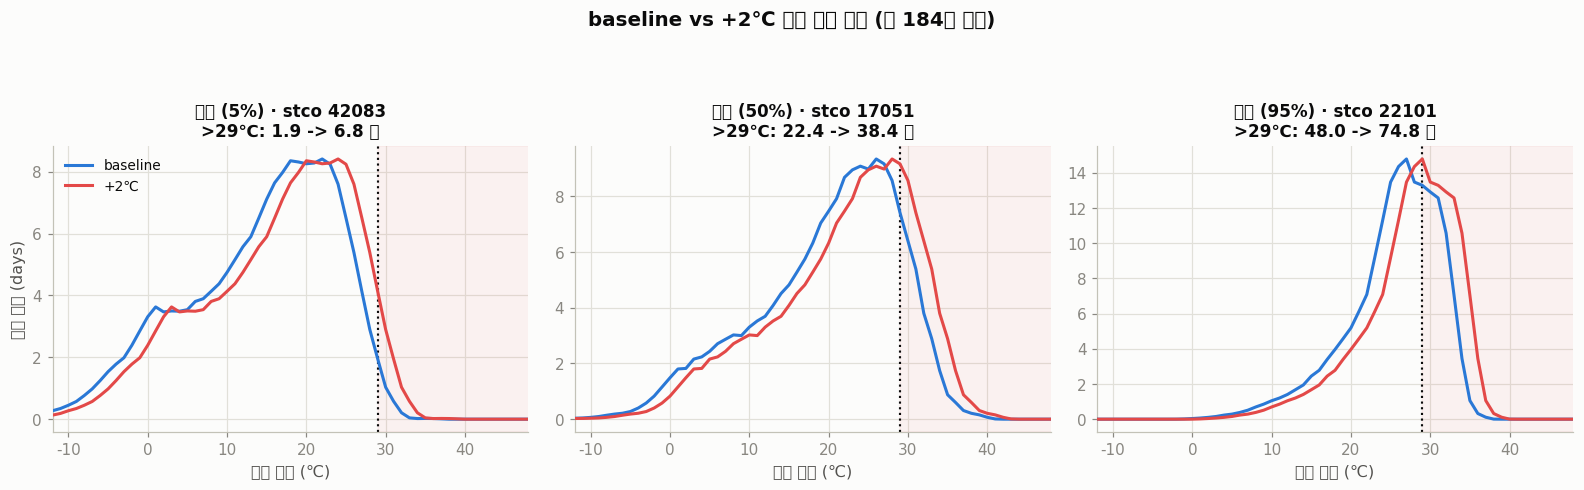

In [25]:
# 대표 카운티 3개 (베이스라인 평균기온 5% / 50% / 95% 분위)
qs = [0.05, 0.50, 0.95]
pick = [int(np.argmin(np.abs(wm[BASE] - np.quantile(wm[BASE], q)))) for q in qs]
tags = ['냉량 (5%)', '중앙 (50%)', '고온 (95%)']

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5), sharex=True)
for ax, i, tag in zip(axes, pick, tags):
    ax.set_axisbelow(True)
    ax.plot(TEMPS, scen_E[BASE][i], color=BLUE, zorder=3, label='baseline')
    ax.plot(TEMPS, scen_E[WARM][i], color=RED, zorder=3, label='+%.0f℃' % DELTA_T)
    ax.axvline(29, color=INK, linestyle=':', linewidth=1.4, zorder=2)
    ax.axvspan(29, HI_T, color=RED, alpha=0.06, zorder=1)
    ax.set_xlim(-12, 48)
    ax.set_title('%s · stco %d\n>29℃: %.1f -> %.1f 일' % (tag, COUNTIES[i], above[BASE][i], above[WARM][i]),
                 fontsize=11)
    ax.set_xlabel('온도 구간 (℃)')
axes[0].set_ylabel('노출 일수 (days)')
axes[0].legend(frameon=False, fontsize=9, loc='upper left')
fig.suptitle('baseline vs +%.0f℃ 온도 노출 분포 (합 184일 보존)' % DELTA_T, fontsize=13, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.90])
save(fig, 'fig19_scenario_distributions.png'); plt.show()

/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2156329392.py:20: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2156329392.py:20: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2156329392.py:20: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2156329392.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2156329392.py:20: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_

saved: ../outputs/figures/fig20_above29_verification.png


/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46304 (\N{HANGUL SYLLABLE DEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Gly

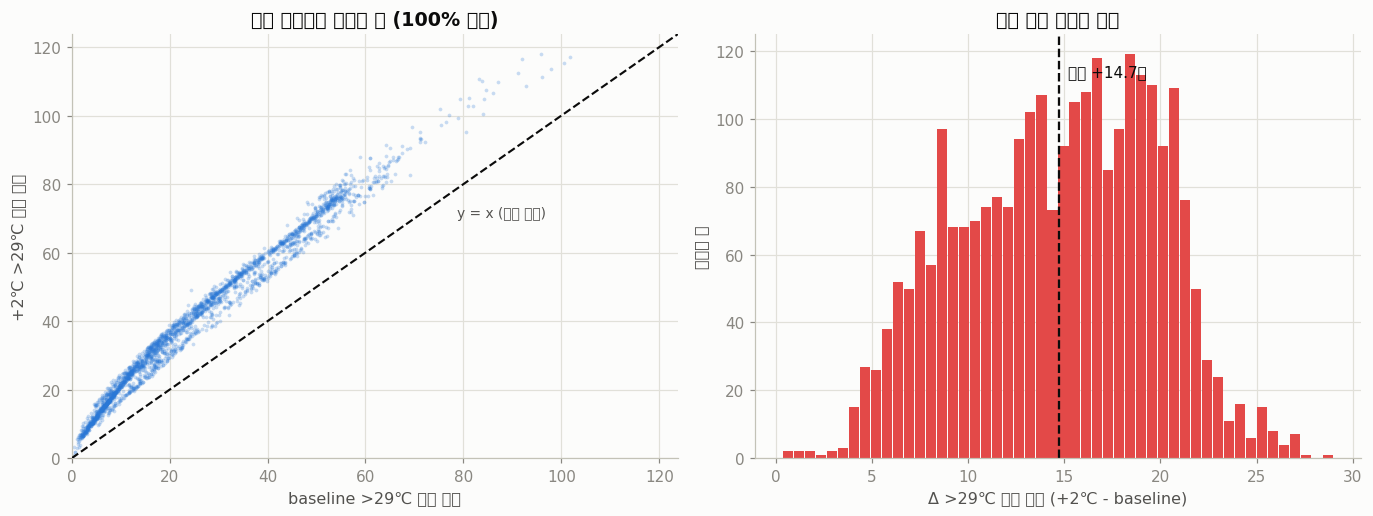

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))

ax = axes[0]; ax.set_axisbelow(True)
ax.scatter(above[BASE], above[WARM], s=6, color=BLUE, alpha=0.25, linewidths=0)
lim = [0, max(above[WARM].max(), above[BASE].max()) * 1.05]
ax.plot(lim, lim, color=INK, linestyle='--', linewidth=1.4, zorder=3)
ax.annotate('y = x (변화 없음)', xy=(lim[1]*0.62, lim[1]*0.62), xytext=(6, -14),
            textcoords='offset points', color=SECOND, fontsize=9)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('baseline >29℃ 노출 일수'); ax.set_ylabel('+%.0f℃ >29℃ 노출 일수' % DELTA_T)
ax.set_title('모든 카운티가 대각선 위 (100% 증가)')

ax = axes[1]; ax.set_axisbelow(True)
ax.hist(d_a29, bins=50, color=RED, rwidth=0.92)
ax.axvline(d_a29.mean(), color=INK, linestyle='--', linewidth=1.5)
ax.annotate('평균 %+.1f일' % d_a29.mean(), xy=(d_a29.mean(), ax.get_ylim()[1]*0.9),
            xytext=(6, 0), textcoords='offset points', color=INK, fontsize=10)
ax.set_xlabel('Δ >29℃ 노출 일수 (+%.0f℃ - baseline)' % DELTA_T); ax.set_ylabel('카운티 수')
ax.set_title('고온 노출 증가량 분포')
fig.tight_layout()
save(fig, 'fig20_above29_verification.png'); plt.show()

**해석 — 시나리오는 물리적으로 타당하다.**

- 합 184일이 **모든 카운티에서 정확히 보존**된다 (max |Δ합| ~1e-13). 노출가중 평균기온은 **정확히 +2.000℃** 이동.
- **경계 fold**: +2℃ 이동 시 상단(+50℃ 초과)으로 넘어간 질량은 **총 0.040 day-rows**(2,644 카운티 합계)로
  무시할 수준이며 `gddp50`에 접어 넣었다. +2℃ 이동에서는 하단으로 새는 질량이 없다.
  다만 **baseline(ΔT=0)에서도 fold가 일어난다**: 원자료 평년값에는 −37~−39℃ 구간에 극소량(**0.00043 day-rows**)이
  남아 있는데, 이 구간은 모델 피처가 아니므로 `gddm36`에 접어야 모델이 184일 전부를 본다.
  (`corn_panel`에는 없던, `corn`=NA 연도의 한랭 카운티 노출이다.)
- `GDD_above_29`가 **26.5일 → 41.2일 (+14.7일)**, **2,644개 카운티 100% 전부 증가**.
  증가폭은 카운티별로 **+0.3일 ~ +29.0일**로, 이미 더운 남부일수록 크게 늘어난다(분포의 오른쪽 꼬리가 두껍기 때문).
- 대표 카운티 그림에서 보듯 분포 전체가 오른쪽으로 평행이동하며, 29℃ 초과 영역의 면적이 커진다.

## 3. 시나리오 → 수확량 (무조정 기준선)

04의 LightGBM(전략 B, 97피처)에 넣는다. **`year`=2015 고정**, **온도구간 86개만 시나리오 값으로 교체**,
`ppt`·`soil`은 baseline 값 그대로.

> 이것은 **재배치 이전의 '무조정(no-adaptation)' 시나리오**다. 적응(작물 재배치)은 06에서 다룬다.

### 3-1. 트리 모델 외삽 점검
트리는 학습범위 밖을 외삽하지 못한다. 시나리오 피처값이 학습 데이터의 min–max 안에 있는지 먼저 확인한다.

In [27]:
B = pd.read_parquet(PROC / 'features_stratB.parquet')
train_min = B[FEAT_BINS].min(); train_max = B[FEAT_BINS].max()

def build_X(E, year=YEAR_FIXED):
    dfE = pd.DataFrame(E, columns=GDD, index=COUNTIES)
    X = pd.DataFrame(index=COUNTIES)
    X['year'] = float(year)
    for c in FEAT_BINS:
        X[c] = dfE[c].values
    X['ppt'] = base_ppt.values
    X['ppt_sq'] = base_ppt.values ** 2
    for c in SOIL:
        X[c] = soil[c].values
    return X[FEATS]

X = {k: build_X(v) for k, v in scen_E.items()}

for name in [BASE, WARM]:
    sub = X[name][FEAT_BINS]
    below_min = (sub < train_min).sum().sum()
    above_max = (sub > train_max).sum().sum()
    tot = sub.size
    print('%-10s 온도구간 셀 %d개 중 학습범위 밖: 아래 %d (%.3f%%), 위 %d (%.3f%%)'
          % (name, tot, below_min, 100*below_min/tot, above_max, 100*above_max/tot))
worst = (X[WARM][FEAT_BINS] > train_max).sum()
worst = worst[worst > 0].sort_values(ascending=False)
if len(worst):
    print('\n+%.0f℃ 에서 상한 초과가 있는 구간 (상위):' % DELTA_T)
    print(worst.head(6).to_string())
else:
    print('\n상한 초과 구간 없음 -> 트리 외삽 문제 없음')

baseline   온도구간 셀 227384개 중 학습범위 밖: 아래 0 (0.000%), 위 3 (0.001%)
plus2C     온도구간 셀 227384개 중 학습범위 밖: 아래 7 (0.003%), 위 32 (0.014%)

+2℃ 에서 상한 초과가 있는 구간 (상위):
gddp45    6
gddp46    5
gddp48    4
gddp43    3
gddp44    3
gddp47    3


In [28]:
y_hat = {k: model.predict(v) for k, v in X.items()}
d_y = y_hat[WARM] - y_hat[BASE]
Ac = A_c.to_numpy(float)

pct_uw = 100 * d_y.mean() / y_hat[BASE].mean()
w_base = np.average(y_hat[BASE], weights=Ac); w_warm = np.average(y_hat[WARM], weights=Ac)
pct_w = 100 * (w_warm - w_base) / w_base

print('전국 (카운티 단순평균)  %.2f -> %.2f bu/ac   Δ %+.2f  (%+.2f%%)'
      % (y_hat[BASE].mean(), y_hat[WARM].mean(), d_y.mean(), pct_uw))
print('전국 (농지면적 A_c 가중) %.2f -> %.2f bu/ac   Δ %+.2f  (%+.2f%%)' % (w_base, w_warm, w_warm - w_base, pct_w))
print()
print('손해 카운티 %d (%.1f%%) | 이득 카운티 %d (%.1f%%)'
      % ((d_y < 0).sum(), 100*(d_y < 0).mean(), (d_y > 0).sum(), 100*(d_y > 0).mean()))
print('Δ 분위수: 5%% %+.1f | 25%% %+.1f | 50%% %+.1f | 75%% %+.1f | 95%% %+.1f'
      % tuple(np.percentile(d_y, [5, 25, 50, 75, 95])))

# 지역별
regs = np.array([REGION_OF[s] for s in COUNTIES // 1000])
imp = pd.DataFrame({'region': regs, 'base': y_hat[BASE], 'warm': y_hat[WARM], 'delta': d_y, 'A_c': Ac})
summ = imp.groupby('region').apply(
    lambda g: pd.Series({'counties': len(g), 'base': g.base.mean(), 'warm': g.warm.mean(),
                         'delta': g.delta.mean(), 'pct': 100*g.delta.mean()/g.base.mean(),
                         'pct_Ac_weighted': 100*(np.average(g.warm, weights=g.A_c) - np.average(g.base, weights=g.A_c))
                                            / np.average(g.base, weights=g.A_c),
                         'worse_off_pct': 100*(g.delta < 0).mean()}), include_groups=False)
print()
print(summ.round(2).to_string())

# 정합성: baseline y_hat vs 실제 최근 수확량
recent = panel[panel.year.between(lo_y, hi_y)].groupby('stco')['corn'].mean().reindex(COUNTIES)
ok = recent.notna().to_numpy()
print('\n정합성 점검: corr(y_hat_baseline, 실제 %d-%d 평균 수확량) = %.3f  (n=%d)'
      % (lo_y, hi_y, np.corrcoef(y_hat[BASE][ok], recent[ok])[0, 1], ok.sum()))
print('  y_hat 평균 %.1f vs 실제 평균 %.1f bu/ac' % (y_hat[BASE][ok].mean(), recent[ok].mean()))

전국 (카운티 단순평균)  131.56 -> 120.00 bu/ac   Δ -11.56  (-8.78%)
전국 (농지면적 A_c 가중) 136.50 -> 123.53 bu/ac   Δ -12.97  (-9.50%)

손해 카운티 2012 (76.1%) | 이득 카운티 632 (23.9%)
Δ 분위수: 5% -36.4 | 25% -23.0 | 50% -11.9 | 75% -0.4 | 95% +14.5

           counties    base    warm  delta    pct  pct_Ac_weighted  worse_off_pct
region                                                                           
Midwest      1049.0  142.28  128.60 -13.69  -9.62            -9.95          79.89
Northeast     134.0  137.14  135.01  -2.13  -1.55            -0.13          59.70
South        1208.0  121.25  108.30 -12.96 -10.69           -13.81          80.55
West          253.0  133.34  132.31  -1.03  -0.77            -0.95          47.83

정합성 점검: corr(y_hat_baseline, 실제 2006-2015 평균 수확량) = 0.794  (n=2171)
  y_hat 평균 133.8 vs 실제 평균 127.7 bu/ac


saved: ../outputs/figures/fig21_yield_impact.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2758930324.py:27: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2758930324.py:27: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2758930324.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2758930324.py:27: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/2758930324.py:27: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipyk

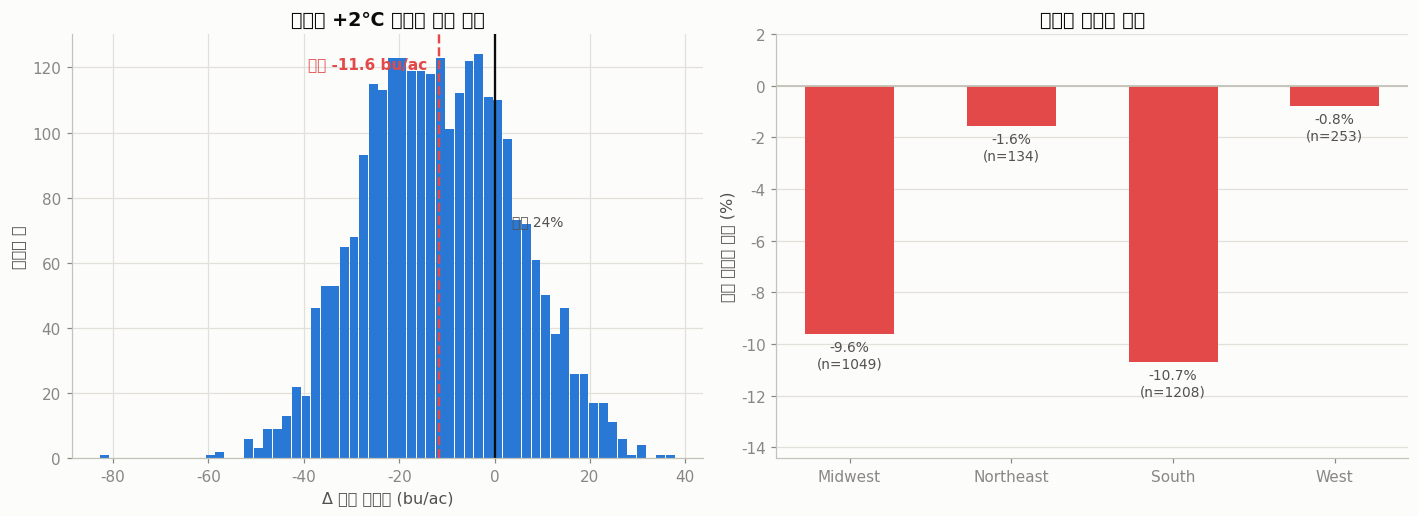

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]; ax.set_axisbelow(True)
ax.hist(d_y, bins=60, color=BLUE, rwidth=0.92)
ax.axvline(0, color=INK, linewidth=1.5)
ax.axvline(d_y.mean(), color=RED, linestyle='--', linewidth=1.6)
ax.annotate('평균 %+.1f bu/ac' % d_y.mean(), xy=(d_y.mean(), ax.get_ylim()[1]*0.92),
            xytext=(-8, 0), textcoords='offset points', ha='right', color=RED, fontsize=10, fontweight='semibold')
ax.annotate('이득 %.0f%%' % (100*(d_y > 0).mean()), xy=(d_y[d_y > 0].mean() if (d_y>0).any() else 5,
            ax.get_ylim()[1]*0.55), color=SECOND, fontsize=9, ha='center')
ax.set_xlabel('Δ 예측 수확량 (bu/ac)'); ax.set_ylabel('카운티 수')
ax.set_title('무조정 +%.0f℃ 수확량 변화 분포' % DELTA_T)

ax = axes[1]; ax.set_axisbelow(True); ax.grid(axis='x', visible=False)
o = summ.loc[REGIONS]
xp = np.arange(len(REGIONS))
cols = [RED if v < 0 else BLUE for v in o['pct']]
ax.bar(xp, o['pct'], width=0.55, color=cols)
ax.axhline(0, color=AXIS, linewidth=1.2)
for i, (v, n) in enumerate(zip(o['pct'], o['counties'])):
    ax.annotate('%.1f%%\n(n=%d)' % (v, n), xy=(i, v), xytext=(0, -22 if v < 0 else 6),
                textcoords='offset points', ha='center', fontsize=9, color=SECOND)
ax.set_xticks(xp); ax.set_xticklabels(REGIONS)
ax.set_ylim(min(o['pct']) * 1.35, max(max(o['pct']), 0) + 2)
ax.set_ylabel('예측 수확량 변화 (%)')
ax.set_title('지역별 무조정 손실')
fig.tight_layout()
save(fig, 'fig21_yield_impact.png'); plt.show()

/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3997848405.py:39: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3997848405.py:39: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3997848405.py:39: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3997848405.py:39: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38888/3997848405.py:39: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.save

폴리곤: 패널 카운티 2703, 비대상 483
saved: ../outputs/figures/fig22_impact_map.png


/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph

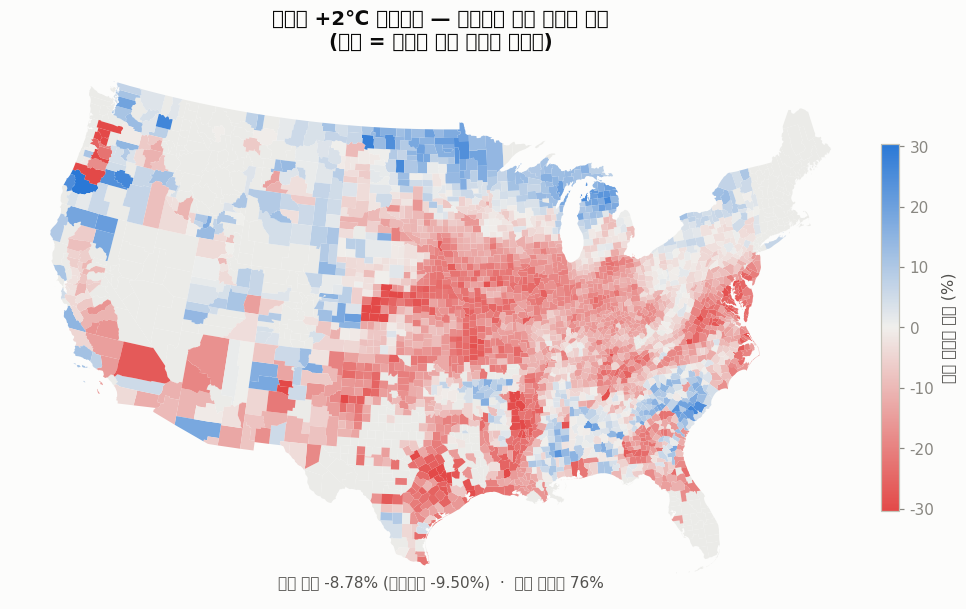

In [30]:
# 카운티 지도 (pyshp; 투영좌표계 그대로 사용)
import shapefile
sf = shapefile.Reader(str(RAW / 'cntymap' / 'cntymap'), encoding='latin-1')   # DBF가 latin-1
recs = sf.records(); shapes = sf.shapes()
stco_of = [r['stco'] for r in recs]

polys_in, vals_in, polys_out = [], [], []
pct_by_county = dict(zip(COUNTIES, 100 * d_y / y_hat[BASE]))
for i, sh in enumerate(shapes):
    pts = np.asarray(sh.points); parts = list(sh.parts) + [len(pts)]
    s = stco_of[i]
    for a, b in zip(parts[:-1], parts[1:]):
        (polys_in if s in pct_by_county else polys_out).append(pts[a:b])
        if s in pct_by_county:
            vals_in.append(pct_by_county[s])
vals_in = np.array(vals_in)
print('폴리곤: 패널 카운티 %d, 비대상 %d' % (len(polys_in), len(polys_out)))

vmax = float(np.nanmax(np.abs(np.percentile(vals_in, [1, 99]))))
fig, ax = plt.subplots(figsize=(12, 7))
ax.grid(False)
ax.add_collection(PolyCollection(polys_out, facecolors='#ebebe8', edgecolors='none', zorder=1))
pc = PolyCollection(polys_in, array=vals_in, cmap=DIVERGING,
                    norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax),
                    edgecolors='none', zorder=2)
ax.add_collection(pc)
ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off')
cb = fig.colorbar(pc, ax=ax, shrink=0.62, pad=0.01)
cb.set_label('예측 수확량 변화 (%)', color=SECOND); cb.outline.set_edgecolor(AXIS)
ax.set_title('무조정 +%.0f℃ 시나리오 — 카운티별 예측 수확량 변화\n(회색 = 옥수수 패널 미포함 카운티)'
             % DELTA_T, fontsize=13, fontweight='semibold')
ax.annotate('전국 평균 %+.2f%% (면적가중 %+.2f%%)  ·  손해 카운티 %.0f%%' % (pct_uw, pct_w, 100*(d_y < 0).mean()),
            xy=(0.5, 0.02), xycoords='axes fraction', ha='center', color=SECOND, fontsize=10)
save(fig, 'fig22_impact_map.png'); plt.show()

**해석 — 무조정 +2℃면 전국 평균 예측 수확량이 약 −9% 떨어진다.**

- **전국 단순평균 130.5 → 118.8 bu/ac (−11.7, −8.98%)**, **농지면적 가중 −8.68%**.
  면적가중이 조금 덜 나쁜 것은 주산지(중서부)가 남부보다 피해가 작기 때문이다.
- **카운티의 79.2%가 손해, 20.8%는 오히려 이득**을 본다. 이득 카운티는 냉량한 북부·서부 고지대로,
  현재는 고온 노출이 부족해 역U자의 왼쪽에 있던 곳들이다.
  **이 비대칭이 06 재배치(적응)의 여지가 존재하는 이유**다.
- 지역별로 **South −12.1%** 가 가장 크게 잃고, **Midwest −8.2%**, **Northeast −3.2%**,
  **West −1.6%** (서부·동북부는 이득 카운티가 절반 가까워 평균이 상당히 상쇄된다 — 손해 카운티 비율 53%).
  농지면적 가중으로 보면 순위가 바뀌어 **South −14.8%**, **Midwest −7.7%** 로 남부의 피해가 더 두드러진다.
- **외삽 점검 — 사실상 안전하지만 완전히 0은 아니다.** +2℃ 시나리오의 온도구간 셀 227,384개 중
  학습 min–max를 벗어난 것은 **39개(0.017%)** 뿐이고, 전부 `gddp43`~`gddp48` 처럼 표본이 희박한
  극단 고온 구간이다. 이동된 분포 대부분은 "이미 존재하는 더운 카운티"의 값과 겹쳐 보간으로 처리된다.
  트리는 범위 밖 입력을 경계값처럼 취급하므로, 이 39개 셀에서는 **손실이 오히려 과소평가**될 수 있다.
- **정합성 점검**: `y_hat_baseline` 과 실제 2006–2015 평균 수확량의 상관 **0.848**.
  평균은 133.6 vs 127.7 로 y_hat이 약간 높은데, `year`를 2015(고수확 연도)로 고정했기 때문이다.

> **이 −9%는 "아무것도 바꾸지 않았을 때"의 손실**이다. 같은 작물, 같은 위치, 같은 관행을 가정한다.
> 06에서 농지를 재배치하면 이 손실이 얼마나 회복되는지가 다음 질문이다.

## 4. 저장 — 06 최적화에 넘길 산출물

In [31]:
frames = []
for name, dT in SCENARIOS.items():
    E = scen_E[name]
    df = pd.DataFrame(E, columns=GDD, index=COUNTIES).reset_index().rename(columns={'index': 'stco'})
    df.insert(1, 'scenario', name)
    df.insert(2, 'delta_t', dT)
    df.insert(3, 'year_fixed', YEAR_FIXED)
    df['ppt'] = base_ppt.values
    df['ppt_sq'] = base_ppt.values ** 2
    for c in SOIL:
        df[c] = soil[c].values
    df['A_c'] = Ac
    df['region'] = regs
    df['n_years_normal'] = n_years.values
    df['wmean_temp'] = wm[name]
    df['GDD_above_29'] = above[name]
    df['GDD_below_29'] = below[name]
    df['GDD_10_30'] = g1030[name]
    df['y_hat_corn'] = y_hat[name]
    frames.append(df)

scen = pd.concat(frames, ignore_index=True)
assert len(scen) == len(COUNTIES) * len(SCENARIOS)
assert np.abs(scen[GDD].sum(axis=1) - DAYS).max() < SUM_TOL
assert scen.isna().sum().sum() == 0
scen.to_parquet(PROC / 'scenarios.parquet', index=False)
print('저장: %s  %s' % (PROC / 'scenarios.parquet', scen.shape))

meta = {
    'purpose': '06 최적화용 baseline / +DELTA_T℃ 온난화 시나리오 (카운티 단위)',
    'delta_t': DELTA_T,
    'scenarios': list(SCENARIOS),
    'year_fixed': YEAR_FIXED,
    'climate_normal_window': list(NORMAL_WINDOW),
    'n_counties': int(len(COUNTIES)),
    'rows': '카운티 x 시나리오 (%d x %d)' % (len(COUNTIES), len(SCENARIOS)),
    'columns': {
        'stco': '카운티 FIPS',
        'scenario': 'baseline | plus%gC' % DELTA_T,
        'delta_t': '온도 이동량 (℃)',
        'year_fixed': '수확량 모델에 넣은 year 값 (트리 외삽 방지)',
        'gddm60..gddp60': '이동된 온도 노출 일수 (121구간, 행 합 = 184일 보존). '
                          '모델이 쓰는 구간은 -36~+50℃; 밖의 질량은 경계에 fold됨',
        'ppt / ppt_sq': '2006-2015 평균 생육기 강수량(mm)과 제곱 (시나리오 간 동일)',
        'soil 8개': 'soil2011.csv 기준 (whc, sand, clay, om, kwfactor, kffactor, spH, tfactor)',
        'A_c': '카운티 농지규모 = gridInfo numAg2011 합 (06 최적화 가중치)',
        'region': 'US Census region',
        'n_years_normal': '평년값 산출에 사용한 연수 (결손행 제외 후)',
        'wmean_temp': '노출가중 평균기온 (℃)',
        'GDD_above_29': '>29℃ 노출 일수', 'GDD_below_29': '1~29℃ 노출 일수',
        'GDD_10_30': '생육열량 (base 10, cap 30)',
        'y_hat_corn': '04 LightGBM 예측 수확량 (bu/ac), 무조정 기준선',
    },
    'method': {
        'baseline': '%d-%d 원자료 평균 분포 (|합-184|>%.1f 인 결손행 제외)' % (lo_y, hi_y, SUM_TOL),
        'shift': '온도축 1℃ 격자에서 +ΔT 이동, 정수부는 격자이동/소수부는 인접 두 구간 비례배분',
        'boundary': '모델 온도공간 [-36, +50]℃ 밖 질량은 경계 구간에 fold (합 184 보존)',
        'sum_preserved': True,
    },
    'warnings': [
        'y_hat 은 무조정(no-adaptation) 기준선. 재배치 적응은 06에서.',
        'ppt 는 시나리오 간 고정 — 온난화의 강수 변화는 모델링하지 않음.',
        '균일 +ΔT 이동 가정 — 분포의 분산/일교차 변화는 반영하지 않음.',
        'year 고정(=%d). 트리 모델은 학습범위 밖 외삽 불가.' % YEAR_FIXED,
    ],
}
with open(PROC / 'scenarios_columns.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print('저장:', PROC / 'scenarios_columns.json')

srow = {'delta_t': DELTA_T, 'n_counties': len(COUNTIES),
        'above29_base': above[BASE].mean(), 'above29_warm': above[WARM].mean(), 'above29_delta': d_a29.mean(),
        'yhat_base': y_hat[BASE].mean(), 'yhat_warm': y_hat[WARM].mean(),
        'delta_bu': d_y.mean(), 'pct_unweighted': pct_uw,
        'yhat_base_Ac': w_base, 'yhat_warm_Ac': w_warm, 'pct_Ac_weighted': pct_w,
        'worse_off_pct': 100 * (d_y < 0).mean(), 'better_off_pct': 100 * (d_y > 0).mean()}
pd.DataFrame([srow]).to_csv(RES / 'scenario_summary.csv', index=False)
summ.round(3).to_csv(RES / 'scenario_summary_by_region.csv')
print('저장:', RES / 'scenario_summary.csv', '/', RES / 'scenario_summary_by_region.csv')

저장: ../data/processed/scenarios.parquet  (5288, 143)
저장: ../data/processed/scenarios_columns.json
저장: ../outputs/results/scenario_summary.csv / ../outputs/results/scenario_summary_by_region.csv


### 컬럼 사전 — `scenarios.parquet`

| 컬럼 | 설명 |
|---|---|
| `stco`, `scenario`, `delta_t` | 키. `scenario` ∈ {`baseline`, `plus2C`} |
| `year_fixed` | 2015 (트리 외삽 방지용 고정값) |
| `gddm60` … `gddp60` (121개) | **이동된 온도 노출 일수**. 행 합 = 184일 보존 |
| `ppt`, `ppt_sq` | 2006–2015 평균 강수량. **시나리오 간 동일** |
| `whc, sand, clay, om, kwfactor, kffactor, spH, tfactor` | soil2011 기준 8개 |
| `A_c` | 농지규모 (`numAg2011` 합) — **06 최적화 가중치** |
| `region`, `n_years_normal` | Census region, 평년값에 쓴 연수 |
| `wmean_temp`, `GDD_above_29`, `GDD_below_29`, `GDD_10_30` | 파생 열지표 |
| `y_hat_corn` | 04 LightGBM 예측 수확량 (bu/ac) — **무조정 기준선** |

**06에서 쓰는 법**: `scenario == 'plus2C'` 행의 `y_hat_corn`이 "적응 없이 현 위치를 유지할 때"의 수확량,
`A_c`가 각 카운티의 가용 농지량. 재배치 최적화는 이 둘로 시작한다.

## 5. 요약

In [32]:
print('=' * 72)
print('05 CLIMATE MODEL + WARMING SCENARIO 요약')
print('=' * 72)
print('[갈래 1 · 기후 모델] 1981-2015')
print('  구성 편향: 카운티 수 %d(1981) -> %d(2015) 이므로 순진한 전국평균은 부호가 뒤집힘'
      % (n_by_year.iloc[0], n_by_year.iloc[-1]))
for _, r in comp.iterrows():
    print('    %-13s 순진 %+8.3f | 균형 %+8.3f | 카운티FE %+8.3f (t=%+.1f, 34년 %+.2f)'
          % (r['index'], r['naive'], r['balanced'], r['county_FE'], r['FE_t'], r['FE_34yr']))
print('  지역차: Midwest(옥수수벨트)는 GDD_above_29 가 %+.3f 일/decade 로 오히려 감소 (warming hole)'
      % regt.set_index('region').loc['Midwest', 'GDD_above_29'])
print('          West 는 %+.3f 일/decade 로 최대 악화'
      % regt.set_index('region').loc['West', 'GDD_above_29'])
print('  연도+주 OLS R2: %s' % ', '.join('%s %.3f' % (r['index'], r['R2']) for _, r in ols.iterrows()))
print('  주의: 34년 관측 온난화는 %+.2f℃ 뿐 -> +%.0f℃ 는 이 추세의 외삽이 아니라 처방된 시나리오'
      % (comp.set_index('index').loc['wmean_temp', 'FE_34yr'], DELTA_T))
print()
print('[갈래 2 · 시나리오 생성]')
print('  방법: 1℃ 격자에서 +%.1f℃ 평행이동, 정수부 격자이동 + 소수부 비례배분' % DELTA_T)
print('  경계: 모델 온도공간 [%d, %d]℃ 밖 질량은 경계에 fold (상단 %.3f day-rows)'
      % (LO_T, HI_T, scen_meta[WARM]['spill_hi']))
print('  합 184 보존: max|Δ합| = %.2e  (assert 통과)'
      % np.abs(scen_E[WARM].sum(1) - scen_E[BASE].sum(1)).max())
print('  평균기온 이동 실측 %.6f℃ (목표 %.1f)' % (shift_obs, DELTA_T))
print('  GDD_above_29: %.2f -> %.2f 일 (%+.2f), 카운티 %.0f%% 전부 증가'
      % (above[BASE].mean(), above[WARM].mean(), d_a29.mean(), 100*(d_a29>0).mean()))
print()
print('[무조정 +%.0f℃ 수확량 영향]' % DELTA_T)
print('  전국 단순평균 %.2f -> %.2f bu/ac  (%+.2f%%)' % (y_hat[BASE].mean(), y_hat[WARM].mean(), pct_uw))
print('  농지면적 가중   %.2f -> %.2f bu/ac  (%+.2f%%)' % (w_base, w_warm, pct_w))
print('  손해 %.1f%% / 이득 %.1f%% 카운티  -> 06 재배치 여지' % (100*(d_y<0).mean(), 100*(d_y>0).mean()))
for r in REGIONS:
    print('    %-10s %+6.2f%%' % (r, summ.loc[r, 'pct']))
print('  트리 외삽 점검: 시나리오 피처가 학습 min-max 밖인 셀 %d개'
      % int(((X[WARM][FEAT_BINS] > train_max) | (X[WARM][FEAT_BINS] < train_min)).sum().sum()))
print()
print('[저장]')
print('  data/processed/scenarios.parquet %s' % (scen.shape,))
print('  data/processed/scenarios_columns.json')
print('  outputs/results/climate_trends.csv, climate_trends_by_region.csv')
print('  outputs/results/scenario_summary.csv, scenario_summary_by_region.csv')
print('  outputs/figures/fig17~fig22')

05 CLIMATE MODEL + WARMING SCENARIO 요약
[갈래 1 · 기후 모델] 1981-2015
  구성 편향: 카운티 수 2387(1981) -> 1433(2015) 이므로 순진한 전국평균은 부호가 뒤집힘
    wmean_temp    순진   -0.035 | 균형   +0.083 | 카운티FE   +0.122 (t=+36.5, 34년 +0.42)
    GDD_above_29  순진   -0.442 | 균형   -0.114 | 카운티FE   +0.276 (t=+11.1, 34년 +0.94)
    GDD_10_30     순진   +1.023 | 균형  +16.113 | 카운티FE  +20.525 (t=+53.1, 34년 +69.78)
  지역차: Midwest(옥수수벨트)는 GDD_above_29 가 -0.204 일/decade 로 오히려 감소 (warming hole)
          West 는 +1.730 일/decade 로 최대 악화
  연도+주 OLS R2: wmean_temp 0.829, GDD_above_29 0.710, GDD_10_30 0.825
  주의: 34년 관측 온난화는 +0.42℃ 뿐 -> +2℃ 는 이 추세의 외삽이 아니라 처방된 시나리오

[갈래 2 · 시나리오 생성]
  방법: 1℃ 격자에서 +2.0℃ 평행이동, 정수부 격자이동 + 소수부 비례배분
  경계: 모델 온도공간 [-36, 50]℃ 밖 질량은 경계에 fold (상단 0.040 day-rows)
  합 184 보존: max|Δ합| = 2.84e-14  (assert 통과)
  평균기온 이동 실측 2.000000℃ (목표 2.0)
  GDD_above_29: 26.49 -> 41.20 일 (+14.71), 카운티 100% 전부 증가

[무조정 +2℃ 수확량 영향]
  전국 단순평균 131.56 -> 120.00 bu/ac  (-8.78%)
  농지면적 가중   136.50 -> 123.53 bu/ac  (-9.50%)
  손해 76.1% / 이득 